In [23]:
# Import Libraries

import pandas as pd
import numpy as np
import torch
import re

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from transformers import AutoTokenizer  # For Tokenization for BERT

from torch.utils.data import Dataset    # To patch all the encoding in single datasets
from torch.utils.data import DataLoader # Sends samples to BERT in pack of chunks to fasten up traning

# BERT Model for classification
from transformers import AutoModelForSequenceClassification

# Optimizer for BERT
from torch.optim import AdamW

# Loss function for clasification 
from torch.nn import CrossEntropyLoss

In [24]:
# Check for GPU
print(torch.cuda.is_available())

True


In [25]:
# store the gpu
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using Device :  {device}")  

Using Device :  cuda


In [26]:
# Load the data

df = pd.read_csv("IMDB.csv")
print(df.head())

                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


In [27]:
df.shape

(50000, 2)

In [28]:
df['sentiment'].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

In [29]:
df.isnull().sum()

review       0
sentiment    0
dtype: int64

In [30]:
# Label Encoding
df['label'] = df['sentiment'].map({'positive':1, 'negative':0})
print(df.head())

                                              review sentiment  label
0  One of the other reviewers has mentioned that ...  positive      1
1  A wonderful little production. <br /><br />The...  positive      1
2  I thought this was a wonderful way to spend ti...  positive      1
3  Basically there's a family where a little boy ...  negative      0
4  Petter Mattei's "Love in the Time of Money" is...  positive      1


In [31]:
# Messy Inputs
df['review'][0]

"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fa

In [32]:
# data proprocessing : Cleaning the text

def clean_text(text):
    
    # Remove html tags
    text = re.sub(r'<.*?>', "", text)   # .*? : anything - characters, numbers, symbols
    
    # Remove numbers
    text = re.sub(r'\d+', "", text)
    
    # Lower case
    text = text.lower()
    
    return text

In [33]:
# Clean dataset text
df['cleaned_review'] = df['review'].apply(clean_text)
print(df['cleaned_review'][0])

one of the other reviewers has mentioned that after watching just  oz episode you'll be hooked. they are right, as this is exactly what happened with me.the first thing that struck me about oz was its brutality and unflinching scenes of violence, which set in right from the word go. trust me, this is not a show for the faint hearted or timid. this show pulls no punches with regards to drugs, sex or violence. its is hardcore, in the classic use of the word.it is called oz as that is the nickname given to the oswald maximum security state penitentary. it focuses mainly on emerald city, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. em city is home to many..aryans, muslims, gangstas, latinos, christians, italians, irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.i would say the main appeal of the show is due to the fact that it goes where other shows woul

In [34]:
print("BEFORE:\n", df['review'][0])
print("\nAFTER:\n", df['cleaned_review'][0])


BEFORE:
 One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due t

In [35]:
# Split the data

train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df['cleaned_review'].values,
    df['label'].values,
    test_size=0.2,
    random_state=42,
    stratify=df['label'].values
)

In [36]:
# Split further into validation and test data

val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts,
    temp_labels,
    test_size=0.5,
    random_state=42,
    stratify=temp_labels
)

In [37]:
print(f"Train size: {len(train_texts)}")
print(f"Validation size: {len(val_texts)}")
print(f"Test size: {len(test_texts)}")

Train size: 40000
Validation size: 5000
Test size: 5000


In [38]:
print(f"Train label distribution: {np.unique(train_labels, return_counts=True)}")
print(f"Val label distribution: {np.unique(val_labels, return_counts=True)}")
print(f"Test label distribution: {np.unique(test_labels, return_counts=True)}")

Train label distribution: (array([0, 1]), array([20000, 20000]))
Val label distribution: (array([0, 1]), array([2500, 2500]))
Test label distribution: (array([0, 1]), array([2500, 2500]))


In [39]:
# Tokenization
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')  # Bert's Tokenizer

In [40]:
sample_text = "I love this man prem !!"
tokens = tokenizer(sample_text)
print(tokens)

{'input_ids': [101, 1045, 2293, 2023, 2158, 26563, 999, 999, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1]}


In [41]:
print(tokenizer.convert_ids_to_tokens(tokens['input_ids']))

['[CLS]', 'i', 'love', 'this', 'man', 'prem', '!', '!', '[SEP]']


In [42]:
sample_texts = ["I loved this movie !!", "Bad."]
tokens = tokenizer(
    sample_texts,
    padding = True,
    truncation = True,
    max_length=20,
    return_tensors = 'pt'
)

print("input_ids:\n", tokens['input_ids'])
print("\nattention_mask:\n", tokens['attention_mask'])

# This showa the example of padding. where sentence Bad. is short so to satisfy the max length criteria the blank spaces are filled by 0s
# So in attention mask this padding are valued as 0 so BERT shouldn't waste its time finding meaning in this padding value

input_ids:
 tensor([[ 101, 1045, 3866, 2023, 3185,  999,  999,  102],
        [ 101, 2919, 1012,  102,    0,    0,    0,    0]])

attention_mask:
 tensor([[1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 0, 0, 0, 0]])


Tokenizer : It converts raw text into three arrays that BERT can understand — input_ids, attention_mask and token_type_ids.

In [43]:
# For choosing max length of tokens, need to analyze avg and max of entire dataset
lengths = df['cleaned_review'].apply(lambda x: len(tokenizer.tokenize(x)))
print(f"Average length: {lengths.mean()}")
print(f"Max length: {lengths.max()}")
print(f"90th percentile: {lengths.quantile(0.90)}")

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (529 > 512). Running this sequence through the model will result in indexing errors


Average length: 290.72204
Max length: 3038
90th percentile: 569.0


In [44]:
# 90th percentile means — 90% of our reviews are under 569 tokens. So if we set max_length=256, 
# we're covering the majority of reviews reasonably well. The very long ones just get cut off a little.

MAX_LENGTH = 256

train_encodings = tokenizer(
    list(train_texts),
    padding = True,
    truncation = True,
    max_length = MAX_LENGTH,
    return_tensors = 'pt'
)

In [45]:
# Tokenizing Validation Set

val_encodings = tokenizer(
    list(val_texts),
    padding = True,
    truncation = True,
    max_length = MAX_LENGTH,
    return_tensors = 'pt'
)

In [46]:
# Tokenizing Test Set

test_encodings = tokenizer(
    list(test_texts),
    padding = True,
    truncation = True,
    max_length = MAX_LENGTH,
    return_tensors = 'pt'
)

In [47]:
# validate tokenization

print(f"Train input_ids shape : {train_encodings['input_ids'].shape}")
print(f"Validation input_ids shape : {val_encodings['input_ids'].shape}")
print(f"Test input_ids shape : {test_encodings['input_ids'].shape}")

Train input_ids shape : torch.Size([40000, 256])
Validation input_ids shape : torch.Size([5000, 256])
Test input_ids shape : torch.Size([5000, 256])


In [48]:
# Encodings are in seperate variables - Patch them together in specific format using Pytorch so model can be feeded

class IMDBDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels
        
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        item = {key : val[idx] for key, val in self.encodings.items()}  # Dictionary Comprehension
        item['labels'] = torch.tensor(self.labels[idx])
        # Stores the desried index data in dictionary item and returns it 
        return item
    
        # So when PyTorch asks for sample 5, it gets back a neat dictionary:
        # {
        #   'input_ids': tensor of 256 numbers,
        #   'attention_mask': tensor of 256 numbers,
        #   'labels': tensor(1)  # positive
        # }

In [49]:
# Create Three dataset object

train_dataset = IMDBDataset(train_encodings, train_labels)
val_dataset = IMDBDataset(val_encodings, val_labels)
test_dataset = IMDBDataset(test_encodings, test_labels)

In [50]:
print(f"Train dataset size: {len(train_dataset)}")
print(f"Val dataset size: {len(val_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

Train dataset size: 40000
Val dataset size: 5000
Test dataset size: 5000


In [51]:
# Dataloader for batches 

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

In [52]:
# Load actual Model

model = AutoModelForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels = 2  # Our classification has 2 output +ve or -ve
)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3563.16it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoi

In [53]:
print(model)

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [54]:
# Move Model to GPU

model = model.to(device)
print(f"Model is on {next(model.parameters()).device}")

Model is on cuda:0


In [55]:
# Optimizer for BERT
optimizer = AdamW(model.parameters(), lr=2e-5)

In [56]:
# Loss function for classification
loss_fn = CrossEntropyLoss()

In [57]:
# One full pass through all 40,000 training samples = one epoch.

# Traning Loop for BERT

def train_epoch(model, dataloader, optimizer, device):
    # Set to traning mode
    model.train()
    total_loss = 0
    
    for batch in dataloader:
        # Zero out the gradient
        optimizer.zero_grad()
        
        # Move batch to GPU
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        
        # Forward pass - Feed data to BERT and get predictions
        outputs = model(
            input_ids= input_ids,
            attention_mask = attention_mask,
            labels = labels     # as we pass labels directly into model, loss is calculated internally, so here is no use of loss_fn we created earlier
        )
        
        # back propogation
        outputs.loss.backward()
        
        # update weights
        optimizer.step()
        
        total_loss += outputs.loss.item()
        
    return total_loss/len(dataloader)
        

In [58]:
#  Evaluation function

def evaluate(model, dataloader, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            outputs = model(
                input_ids = input_ids,
                attention_mask = attention_mask,
                labels = labels
            )
            
            total_loss += outputs.loss.item()
            
            # Get pridiction from logits
            preds = torch.argmax(outputs.logits, dim=1)
            
            all_preds.extend(preds.cpu().numpy())   
            all_labels.extend(labels.cpu().numpy())
            
        return total_loss/len(dataloader), all_preds, all_labels


#### Train BERT : ALL Layers

In [44]:
EPOCHS = 3

for epoch in range(EPOCHS):
    print(f"Epoch {epoch}/{EPOCHS}")
    print("-"*30)
    
    train_loss = train_epoch(model, train_loader, optimizer, device)
    print(f"Train Loss : {train_loss:.4f}")
    
    val_loss, val_preds, val_labels = evaluate(model, val_loader, device)
    print(f"Val Loss : {val_loss:.4f}")


Epoch 0/3
------------------------------
Train Loss : 0.0247
Val Loss : 0.2707
Epoch 1/3
------------------------------
Train Loss : 0.0216
Val Loss : 0.3536
Epoch 2/3
------------------------------
Train Loss : 0.0174
Val Loss : 0.3891


In [59]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

test_loss, test_preds, test_labels_list = evaluate(model, test_loader, device)

In [60]:
accuracy = accuracy_score(test_labels_list, test_preds)
precision = precision_score(test_labels_list, test_preds)
recall = recall_score(test_labels_list, test_preds)
f1 = f1_score(test_labels_list, test_preds)

print(f"Test Accuracy : {accuracy:.4f}")
print(f"Test Precision : {precision:.4f}")
print(f"Test Recall : {recall:.4f}")
print(f"Test F1 Score : {f1:.4f}")

Test Accuracy : 0.5030
Test Precision : 0.5773
Test Recall : 0.0224
Test F1 Score : 0.0431


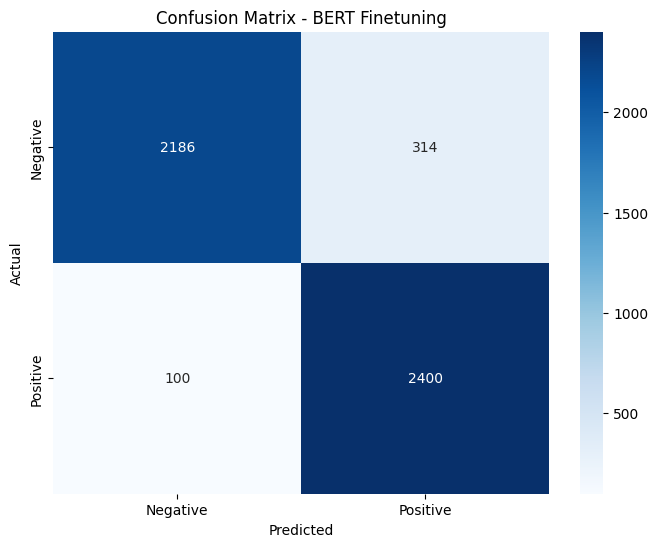

In [53]:
cm = confusion_matrix(test_labels_list, test_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title("Confusion Matrix - BERT Finetuning")
plt.show()

## Experiment 2 : Freezing all layers of BERT | Only train Classifier Layer 

In [84]:
#  Load new model

model_exp2 = AutoModelForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels =2
)

model_exp2 = model_exp2.to(device)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1076.29it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoi

In [87]:
# Freeze all BERT Parameters

for param in model_exp2.bert.parameters():
    param.requires_grad = False     # This tells PyTorch whether to calculate gradients for that parameter during backpropagation.
    
total_params = sum(p.numel() for p in model_exp2.parameters())
trainable_params = sum(p.numel() for p in model_exp2.parameters() if p.requires_grad)

print(f"Total Parameters : {total_params:,}")
print(f"Trainable Parameters : {trainable_params:,}")
print(f"TotaFrozen Parameters : {total_params - trainable_params:,}")


Total Parameters : 109,483,778
Trainable Parameters : 1,538
TotaFrozen Parameters : 109,482,240


Total BERT:     109,483,778 parameters → Frozen ❄️

Classifier:               1,538 parameters → Trainable 🔥

In [88]:
#  Optimizer
optimizer_exp2 = AdamW(
    filter(lambda p: p.requires_grad, model_exp2.parameters()),
    lr=2e-5
)

In [89]:
#  Train model
print("Training EXP : 2 - Frozen BERT")

EPOCHS = 3

for epoch in range(EPOCHS):
    
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print("-"*30)
    
    train_loss = train_epoch(model_exp2, train_loader, optimizer_exp2, device)
    print(f"Train Loss: {train_loss:.4f}")
    
    val_loss, val_pred , val_labels_list = evaluate(model_exp2, val_loader, device)
    val_accuracy = accuracy_score(val_labels_list, val_pred)
    
    print(f"Val Loss : {val_loss:.4f}")
    print(f"Val Accuracy : {val_accuracy:.4f}")

Training EXP : 2 - Frozen BERT

Epoch 1/3
------------------------------
Train Loss: 0.6779
Val Loss : 0.6539
Val Accuracy : 0.6566

Epoch 2/3
------------------------------
Train Loss: 0.6446
Val Loss : 0.6260
Val Accuracy : 0.6976

Epoch 3/3
------------------------------
Train Loss: 0.6224
Val Loss : 0.6119
Val Accuracy : 0.6798


In [90]:
#  Final Metrics for EXP 2
test_loss, test_pred_exp2, test_labels_exp2 = evaluate(model_exp2, test_loader, device)

accuracy_exp2 = accuracy_score(test_labels_exp2, test_pred_exp2)
precision_exp2 = precision_score(test_labels_exp2, test_pred_exp2)
recall_exp2 = recall_score(test_labels_exp2, test_pred_exp2)
f1_exp2 = f1_score(test_labels_exp2, test_pred_exp2)

print(f"Test Accuracy: {accuracy_exp2:.4f}")
print(f"Test Precision: {precision_exp2:.4f}")
print(f"Test Recall: {recall_exp2:.4f}")
print(f"Test F1 Scrore: {f1_exp2:.4f}")


Test Accuracy: 0.6808
Test Precision: 0.6294
Test Recall: 0.8792
Test F1 Scrore: 0.7336


In [91]:
# Store the EXP2 Results
exp2_results = {
    'accuracy' : 0.6808,
    'precision' : 0.6294,
    'recall' : 0.8792,
    'f1' : 0.8792
}

## Experiment 3 : Finetuning Last 2 layer of BERT

In [71]:
#  load model

model_exp3 = AutoModelForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels = 2
)

model_exp3 = model_exp2.to(device)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1444.22it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoi

In [72]:
# 1. First Freeze Every Layer
for param in model_exp3.bert.parameters():
    param.requires_grad = False
    
#  BERTS 12 layers are stored in a list and can be accessed like :
# model.bert.encoder.layer[0] : First Layer
# model.bert.encoder.layer[1] : Second Layer
# ...
# # model.bert.encoder.layer[11] : Second Last Layer

#  Unfreeze last 2 layers of bert

for param in model_exp3.bert.encoder.layer[10].parameters():
    param.requires_grad = True
    
for param in model_exp3.bert.encoder.layer[11].parameters():
    param.requires_grad = True

In [73]:
# Total Parameter
total_params = sum(p.numel() for p in model_exp3.parameters())
trainable_params = sum(p.numel() for p in model_exp3.parameters() if p.requires_grad)

print(f"Total Parameters : {total_params:,}")
print(f"Trainabale Parameters : {trainable_params:,}")


Total Parameters : 109,483,778
Trainabale Parameters : 14,177,282


In [74]:
#  Optimizer for EXP3
optimizer_exp3 = AdamW(
    filter(lambda p: p.requires_grad, model_exp3.parameters()),
    lr=2e-5
)

In [75]:
#  Train Model
print("Training Experiment 3 - Last 2 Layers + Classifier ")

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print("-"*30)
    
    train_loss = train_epoch(model_exp3, train_loader, optimizer_exp3, device)
    print(f"Train Loss : {train_loss:.4f}")
    
    val_loss, val_pred, val_labels_list = evaluate(model_exp3, val_loader, device)
    val_accuracy = accuracy_score(val_labels_list, val_pred)
    
    print(f"Val Loss : {val_loss:.4f}")
    print(f"Val Accuracy : {val_accuracy:.4f}")

Training Experiment 3 - Last 2 Layers + Classifier 

Epoch 1/3
------------------------------
Train Loss : 0.2774
Val Loss : 0.2277
Val Accuracy : 0.9072

Epoch 2/3
------------------------------
Train Loss : 0.2225
Val Loss : 0.2225
Val Accuracy : 0.9128

Epoch 3/3
------------------------------
Train Loss : 0.1965
Val Loss : 0.2247
Val Accuracy : 0.9154


In [80]:
#  Final Metrics

test_loss, test_pred_exp3, test_labels_exp3 = evaluate(model_exp3, test_loader, device)

accuracy_exp3 = accuracy_score(test_labels_exp3, test_pred_exp3)
precision_exp3 = precision_score(test_labels_exp3, test_pred_exp3)
recall_exp3 = recall_score(test_labels_exp3, test_pred_exp3)
f1_exp3 = f1_score(test_labels_exp3, test_pred_exp3)

print(f"Test Accuracy : {accuracy_exp3:.4f}")
print(f"Test Precision : {precision_exp3:.4f}")
print(f"Test Recall : {recall_exp3:.4f}")
print(f"Test F1 Score : {f1_exp3:.4f}")

Test Accuracy : 0.9192
Test Precision : 0.9021
Test Recall : 0.9404
Test F1 Score : 0.9209


In [81]:
print("=" * 60)
print("FINAL EXPERIMENT COMPARISON")
print("=" * 60)
print(f"{'Metric':<15} {'Exp1-Full':>12} {'Exp2-Frozen':>12} {'Exp3-Last2':>12}")
print("-" * 60)
print(f"{'Accuracy':<15} {'0.9172':>12} {'0.6916':>12} {'0.9192':>12}")
print(f"{'Precision':<15} {'0.8843':>12} {'0.6405':>12} {'0.9021':>12}")
print(f"{'Recall':<15} {'0.9600':>12} {'0.8736':>12} {'0.9404':>12}")
print(f"{'F1 Score':<15} {'0.9206':>12} {'0.7391':>12} {'0.9209':>12}")
print(f"{'Trainable':>15} {'109M':>12} {'1.5K':>12} {'14M':>12}")
print("=" * 60)

FINAL EXPERIMENT COMPARISON
Metric             Exp1-Full  Exp2-Frozen   Exp3-Last2
------------------------------------------------------------
Accuracy              0.9172       0.6916       0.9192
Precision             0.8843       0.6405       0.9021
Recall                0.9600       0.8736       0.9404
F1 Score              0.9206       0.7391       0.9209
      Trainable         109M         1.5K          14M


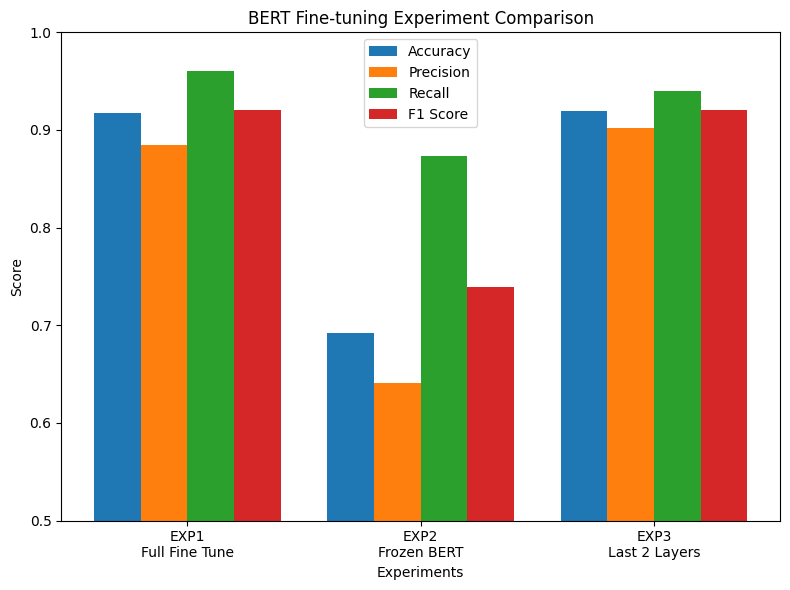

In [102]:
#  Beautiful Visualization

experiments = ['EXP1\nFull Fine Tune', 'EXP2\nFrozen BERT', 'EXP3\nLast 2 Layers']
metrics = {
    'Accuracy':  [0.9172, 0.6916, 0.9192],
    'Precision': [0.8843, 0.6405, 0.9021],
    'Recall':    [0.9600, 0.8736, 0.9404],
    'F1 Score':  [0.9206, 0.7391, 0.9209]
}

x = np.arange(len(experiments)) # creates an array with specified range : (0,1,2,...)
width = 0.2

fig, ax = plt.subplots(figsize=(8,6))

for i, (metric, values) in enumerate(metrics.items()):
    ax.bar(x + i*width, values, width, label = metric)
    
ax.set_xlabel('Experiments')
ax.set_ylabel('Score')
ax.set_title("BERT Fine-tuning Experiment Comparison")
ax.set_xticks(x + width*1.5)
ax.set_xticklabels(experiments)
ax.legend()
ax.set_ylim(0.5, 1.0)
plt.tight_layout()
plt.show()

#### As per the Visualization we can Conclude that Model with Finetuning of Last 2 Layers performs better as much as finetuning all the layers. So Exp 3 model Wins.

## Prediction Function

In [107]:
def predict_sentiment(review, model, tokenizer, device):
    # Step 1 : Clean the text
    cleaned = clean_text(review)
    
    # Step 2 : Tokenize
    encoding = tokenizer(
        cleaned,
        truncation=True, 
        padding='max_length',
        max_length=256,
        return_tensors = 'pt'
    )
    
    # Step 3 : Move to GPU
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)
    
    # Step 4 : Evaluation mode and no gradient tracking
    model.eval()
    
    with torch.no_grad():
        outputs = model(
            input_ids = input_ids,
            attention_mask = attention_mask
        )
        
    # Step 5 : Get predictions from output.logits - as they give us numbers [0.12, 0.92]
    prediction = torch.argmax(outputs.logits, dim = 1).item()
    
    # Step 6 : Convert the predictions to Labels
    return "Positive 😊" if prediction == 1 else "Negative 😞" 

#### Test the Model

In [109]:
reviews = [
    "This movie was absolutely brilliant! I loved every second of it.",
    "Terrible movie, complete waste of time. Awful acting.",
    "It was okay, nothing special but not bad either."
]

for review in reviews:
    result = predict_sentiment(review, model_exp3, tokenizer, device)
    print(f"Review : {review[:50]}...")
    print(f"Sentiment : {result}")
    print("-"*50)

Review : This movie was absolutely brilliant! I loved every...
Sentiment : Positive 😊
--------------------------------------------------
Review : Terrible movie, complete waste of time. Awful acti...
Sentiment : Negative 😞
--------------------------------------------------
Review : It was okay, nothing special but not bad either....
Sentiment : Negative 😞
--------------------------------------------------
